
# EDA: NUREG/KM-0011 Table 4-2 Source Dataset Ranges (`nureg_km0011_table4-2_source_dataset_ranges.csv`)

The largest range-summary table (72 source studies) underlying the
NUREG/KM-0011 CHF compilation. Columns are already split into `_min`/`_max`
pairs per variable, but several are stored as thousands-separated strings
(e.g. `"9,800"`) and need cleaning before use.

## 1. Load Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 100

DATA_DIR = Path("../../data/raw/external")
OUT_DIR = Path("../../results/eda/nureg_km0011_table4-2_source_dataset_ranges")
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_DIR / "nureg_km0011_table4-2_source_dataset_ranges.csv")
df

,name,N_points,D_mm_min,D_mm_max,L_m_min,L_m_max,P_kPa_min,P_kPa_max,G_kg_m2s_min,G_kg_m2s_max,Xchf_min,Xchf_max,DHin_kJkg_min,DHin_kJkg_max,q_kWm2_min,q_kWm2_max,Tin_C_min,Tin_C_max,_source_pdf_page
0,Alekseev (1964) data from Kirillov (1992),70,10.00,10.01,1.000,4.966,"9,800","19,610",216,"7,566",-0.866,0.944,57,"1,398",134,"4,949",139.77,357.93,25
1,Alessandrini et (1963),753,15.2,24.9,0.800,2.460,"4,795","5,148","1,080","4,140",-0.040,0.750,"-1,110",365,206,"3,689",185.00,265.00,25
2,Babarin et al. (1969),163,12.0,12.0,0.960,1.800,284,310,50,500,0.466,1.091,37.6,495,190,"2,300",15.00,124.00,25
3,Babcock and Hood (1962),39,8.00,22.5,0.610,0.610,413,"6,890","2,946","11,452",-0.187,-0.050,202,639,"4,876","10,546",19.00,177.00,25
4,Baek (2001),56,6.00,10.0,0.180,0.400,101,"3,618",497,"2,032",-0.091,0.099,254,935,"2,041","7,413",5.90,40.20,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,Yildiz (1997),385,6.00,8.00,0.170,0.310,90,721,48.5,411,0.001,0.914,-4.26,"1,057",533,"4,381",31.00,158.00,32
68,Yin et al. (1988) Zenkevich (1969),287,13.40,3.99,3.658,0.250,"1,028","5,880","1,938.9",498,0.075,-1.652,0,2,583.3,136,128.42,76.01,32
69,data from Kirillov (1992) Zenkevich (1971) dat...,392,15.10,8.05,6.000,20.000,"19,610","17,650","9,876","2,783",0.964,0.876,"1,644","1,549","14,760","1,283",361.79,352.22,32
70,Zenkevich et al. (1974) data different from th...,823,4.80,12.60,1.000,6.000,"5,890","19,620",497.2,"6,694.4",-0.221,0.969,5,"1,381",230,"4,740",96.70,358.24,32



## 2. Clean Numeric Columns

A handful of cells in this source table contain free text (`"data"`,
`"distribution"`) instead of a number, alongside a garbled `name` value that
looks like two source citations merged into one row — a digitization
artifact in the underlying NUREG/KM-0011 PDF table extraction. These are
coerced to `NaN` (not dropped) and counted below rather than silently
ignored.


In [2]:
minmax_vars = ["D_mm", "L_m", "P_kPa", "G_kg_m2s", "Xchf", "DHin_kJkg", "q_kWm2", "Tin_C"]
n_coerced = 0
for var in minmax_vars:
    for suffix in ["_min", "_max"]:
        col = f"{var}{suffix}"
        cleaned = df[col].astype(str).str.replace(",", "", regex=False)
        numeric = pd.to_numeric(cleaned, errors="coerce")
        n_coerced += int((numeric.isna() & df[col].notna()).sum())
        df[col] = numeric

print(f"Non-numeric values coerced to NaN: {n_coerced}")
print(df.loc[df[[f'{v}{s}' for v in minmax_vars for s in ('_min', '_max')]].isna().any(axis=1),
             ["name"]])

df.to_csv(OUT_DIR / "parsed_ranges.csv", index=False)
df[["name", "N_points"] + [f"{v}{s}" for v in minmax_vars for s in ("_min", "_max")]].head()

Non-numeric values coerced to NaN: 6
                                                 name
12  Biancone et al. (1965) Borodin and Macdonald (...
21     Dell et al. (1969) AERE-M 2216 Doerffer (1999)
22           Doerffer et al. (1997) Era et al. (1966)
23                Griffel (1965) NYO-187-7 Groeneveld
27                            Hood and Isakoff (1962)
39                    (1990) Lowdermilk et al. (1958)
55                (Private Communication) Shan (2005)


,name,N_points,D_mm_min,D_mm_max,L_m_min,L_m_max,P_kPa_min,P_kPa_max,G_kg_m2s_min,G_kg_m2s_max,Xchf_min,Xchf_max,DHin_kJkg_min,DHin_kJkg_max,q_kWm2_min,q_kWm2_max,Tin_C_min,Tin_C_max
0,Alekseev (1964) data from Kirillov (1992),70,10.0,10.01,1.00,4.966,9800.0,19610.0,216.0,7566.0,-0.866,0.944,57.0,1398,134.0,4949.0,139.77,357.93
1,Alessandrini et (1963),753,15.2,24.90,0.80,2.460,4795.0,5148.0,1080.0,4140.0,-0.040,0.750,-1110.0,365,206.0,3689.0,185.00,265.00
2,Babarin et al. (1969),163,12.0,12.00,0.96,1.800,284.0,310.0,50.0,500.0,0.466,1.091,37.6,495,190.0,2300.0,15.00,124.00
3,Babcock and Hood (1962),39,8.0,22.50,0.61,0.610,413.0,6890.0,2946.0,11452.0,-0.187,-0.050,202.0,639,4876.0,10546.0,19.00,177.00
4,Baek (2001),56,6.0,10.00,0.18,0.400,101.0,3618.0,497.0,2032.0,-0.091,0.099,254.0,935,2041.0,7413.0,5.90,40.20


## 3. Descriptive Stats on Reported Ranges

In [3]:
stats_rows = []
for var in minmax_vars:
    span = df[f"{var}_max"] - df[f"{var}_min"]
    stats_rows.append({
        "variable": var,
        "n_sources": df[f"{var}_min"].notna().sum(),
        "global_min": df[f"{var}_min"].min(),
        "global_max": df[f"{var}_max"].max(),
        "median_span": span.median(),
    })
pd.DataFrame(stats_rows).set_index("variable")

,n_sources,global_min,global_max,median_span
variable,,,,
D_mm,69,0.100,44.700,0.0000
L_m,72,0.002,20.500,0.1420
P_kPa,71,76.500,20265.000,1756.0000
G_kg_m2s,72,10.800,134000.000,3274.1000
Xchf,72,-1.778,1.664,0.4465
DHin_kJkg,72,-1211.000,3433.000,514.5000
q_kWm2,72,84.000,276000.000,4215.0000
Tin_C,72,-20.000,509.300,89.8050


## 4. Range Coverage by Source (one figure per variable — 72 sources)

In [4]:
def plot_range_bars(ax, labels, mins, maxs, title, xlabel=""):
    y = np.arange(len(labels))
    ax.hlines(y, mins, maxs, color="#4C72B0", linewidth=6)
    ax.plot(mins, y, "|", color="#2f4b7c", markersize=14, markeredgewidth=2)
    ax.plot(maxs, y, "|", color="#2f4b7c", markersize=14, markeredgewidth=2)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.invert_yaxis()

In [5]:
order = df.sort_values("q_kWm2_max", ascending=False)["name"]
df_sorted = df.set_index("name").loc[order].reset_index()

for var in minmax_vars:
    fig, ax = plt.subplots(figsize=(8, max(6, 0.22 * len(df_sorted))))
    plot_range_bars(ax, df_sorted["name"], df_sorted[f"{var}_min"], df_sorted[f"{var}_max"], var)
    ax.tick_params(axis="y", labelsize=6)
    fig.suptitle(f"NUREG/KM-0011 Table 4-2: {var} Range by Source", y=1.005)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"range_by_source_{var}.png", dpi=150, bbox_inches="tight")
    plt.close(fig)
print("Saved one range-by-source figure per variable to", FIG_DIR)

Saved one range-by-source figure per variable to ../../results/eda/nureg_km0011_table4-2_source_dataset_ranges/figures


## 5. Points per Source (Top 20)

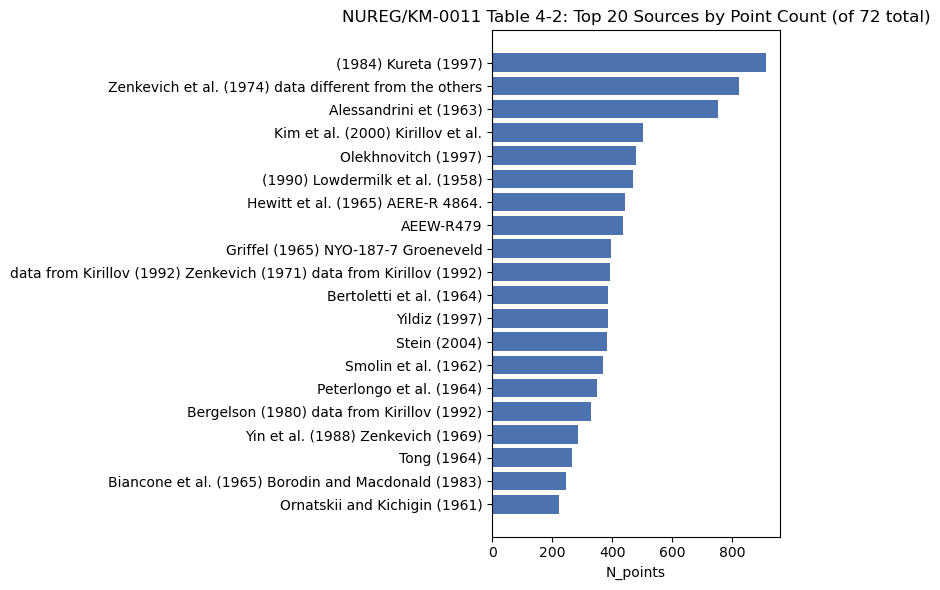

In [6]:
top_n = df.nlargest(20, "N_points")[["name", "N_points"]]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_n["name"][::-1], top_n["N_points"][::-1], color="#4C72B0")
ax.set_xlabel("N_points")
ax.set_title(f"NUREG/KM-0011 Table 4-2: Top 20 Sources by Point Count (of {len(df)} total)")
fig.tight_layout()
fig.savefig(FIG_DIR / "top_sources_by_n_points.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Takeaways

- A handful of rows have digitization artifacts (garbled/merged `name`
  citations, `D_mm_min`/`D_mm_max` cells containing the text `"data"` or
  `"distribution"` instead of a number) — these are coerced to `NaN` rather
  than dropped, so downstream aggregates naturally exclude them but the rows
  remain visible for manual correction against the source PDF.
- 72 source studies span very different pressure/mass-flux/quality windows —
  the per-variable range-by-source figures (saved to `figures/`, one PNG per
  variable since 72 rows don't fit one readable panel) are the primary way
  to spot coverage gaps.
- `_source_pdf_page` is a citation/provenance column (which NUREG/KM-0011 PDF
  page the row was digitized from), not a physical variable — excluded from
  the numeric analysis.
- Name matching against `nureg_km0011_table4-1_SAMPLE_ONLY.csv`'s single
  `Reference` value is not automated (citation formats differ between the two
  files) — see the takeaways note in that notebook.
